In [1]:
# Import modules
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import Polygon

In [2]:
# Load data

# County boundaries
# Source: https://opendata.mtc.ca.gov/datasets/san-francisco-bay-region-counties-clipped?geometry=-125.590%2C37.123%2C-119.152%2C38.640
counties = gpd.read_file("../data/open-GIS/region_county/region_county.shp")

# Well locations
# Source: https://gis.data.ca.gov/datasets/3a3e681b894644a9a95f9815aeeeb57f_0?geometry=-123.143%2C36.405%2C-119.230%2C37.175
# Modified by author so that only the well locations within the counties and the surrounding 50 km were kept
wells = gpd.read_file("../data/open-GIS/i08_GroundwaterStations_EnterpriseWaterManagement/i08_GroundwaterStations_EnterpriseWaterManagement.shp")

/home/the-ape/CurrentProjects/whatsapp-business/DSAI-course/DSAI_env/lib/python3.12/site-packages/pyogrio/raw.py:198: RuntimeWarning: ../data/open-GIS/region_county/region_county.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


In [3]:
# Reproject data to NAD83(HARN) / California Zone 3
# https://spatialreference.org/ref/epsg/2768/
proj = 2768
counties = counties.to_crs(proj)
wells = wells.to_crs(proj)

In [4]:
counties.head()

,fipst,fipco,coname,geometry
0,06,097,None,"POLYGON ((1787066.56 704090.104, 1787074.707 7..."
1,06,075,None,"MULTIPOLYGON (((1828026.871 650402.153, 182677..."
2,06,041,None,"POLYGON ((1798906.44 656381.811, 1798982.726 6..."
3,06,055,None,"POLYGON ((1829172.531 746544.267, 1827998.596 ..."
4,06,095,None,"POLYGON ((1863162.718 702681.284, 1862854.907 ..."


In [5]:
wells.head()

,OBJECTID,SITE_CODE,WELL_NAME,SWN,STN_ID,WCR_NO,LOC_DESC,WELL_USE,WELL_TYPE,WELL_DEPTH,...,MONITORING,LAST_MEAS_,LAST_MEA_1,STN_CMT,STN_MOD_DA,STN_MOD_BY,SOURCE,LAST_UPDAT,GlobalID,geometry
0,1,344238N1196128W001,3-23,None,61095,None,next to house in walled region by trash,Residential,Single Well,435.0,...,SGMA,None,None,None,2024-09-20,None,DWR EWM DB,2024-09-25,{DB05DE98-CBFF-4537-A2C4-3420D4E29784},POINT (2081683.705 269860.261)
1,2,344218N1196224W001,3-24,None,61096,None,near large avo tree and road,Residential,Single Well,325.0,...,SGMA,None,None,None,2024-09-20,None,DWR EWM DB,2024-09-25,{51656FF0-0034-4E7E-B8F0-4DB552122841},POINT (2080799.161 269634.143)
2,3,344192N1196477W001,3-27,None,61097,None,between house and garage in back,Irrigation,Single Well,280.0,...,SGMA,None,None,None,2024-09-20,None,DWR EWM DB,2024-09-25,{91C76CBD-6EAF-421A-A8D0-0CAED39965B7},POINT (2078475.315 269315.999)
3,4,344202N1196262W001,3-28,None,61098,None,in parking lot,Irrigation,Single Well,165.0,...,SGMA,None,None,None,2024-09-20,None,DWR EWM DB,2024-09-25,{1D8B05DC-D338-4A03-9358-2A88ECBA54A8},POINT (2080449.112 269454.201)
4,5,344317N1195730W001,4-4,None,61099,None,above garage and rec building,Irrigation,Single Well,975.0,...,SGMA,None,None,None,2024-09-20,None,DWR EWM DB,2024-09-25,{D0BB90BC-2DD3-441F-9A5C-11F5A9141EB8},POINT (2085336.365 270780.108)


In [6]:
# Create list of coordinate pairs
coordinates = [[1790787, 736108], [1929652, 736108], [1929652, 598414], [1790787, 598414]]

# Create a Shapely polygon from the coordinate-tuple list
poly_shapely = Polygon(coordinates)

# Create a dictionary with needed attributes and required geometry column
attributes_df = {'Attribute': ['name1'], 'geometry': poly_shapely}

# Convert shapely object to a GeoDataFrame
poly = gpd.GeoDataFrame(attributes_df, geometry = 'geometry', crs = "EPSG:2768")

In [7]:
def display_table(table_name, attribute_table):
    '''Display the first and last five rows of attribute table.'''

    # Print title
    print("Attribute Table: {}".format(table_name))

    # Print number of rows and columns
    print("\nTable shape (rows, columns): {}".format(attribute_table.shape))

    # Display first two rows of attribute table
    print("\nFirst two rows:")
    display(attribute_table.head(2))

    # Display last two rows of attribute table
    print("\nLast two rows:")
    display(attribute_table.tail(2))


def plot_df(result_name, result_df, result_geom_type, area = None):
    '''Plot the result on a map and add the outlines of the original shapefiles.'''

    # Create subplots
    fig, ax = plt.subplots(1, 1, figsize = (10, 10))

    # Plot data depending on vector type
    # For points
    if result_geom_type == "point":

        # Plot data
        counties.plot(ax = ax, color = 'none', edgecolor = 'dimgray')
        wells.plot(ax = ax, marker = 'o', color = 'dimgray', markersize = 3)
        result_df.plot(ax = ax, marker = 'o', color = 'dodgerblue', markersize = 3)

    # For polygons
    else:

        # Plot overlay data
        result_df.plot(ax = ax, cmap = 'Set2', edgecolor = 'black')

        # Plot outlines of original shapefiles
        counties.plot(ax = ax, color = 'none', edgecolor = 'dimgray')

    # Add additional outlined boundary if specified
    if area is not None:

        # Plot data
        area.plot(ax = ax, color = 'none', edgecolor = 'lightseagreen', linewidth = 3)

    # Else, pass
    else:
        pass

    # Stylize plots
    plt.style.use('bmh')

    # Set title
    ax.set_title(result_name, fontdict = {'fontsize': '15', 'fontweight' : '3'})

Text(0.5, 1.0, 'San Francisco Bay Area')

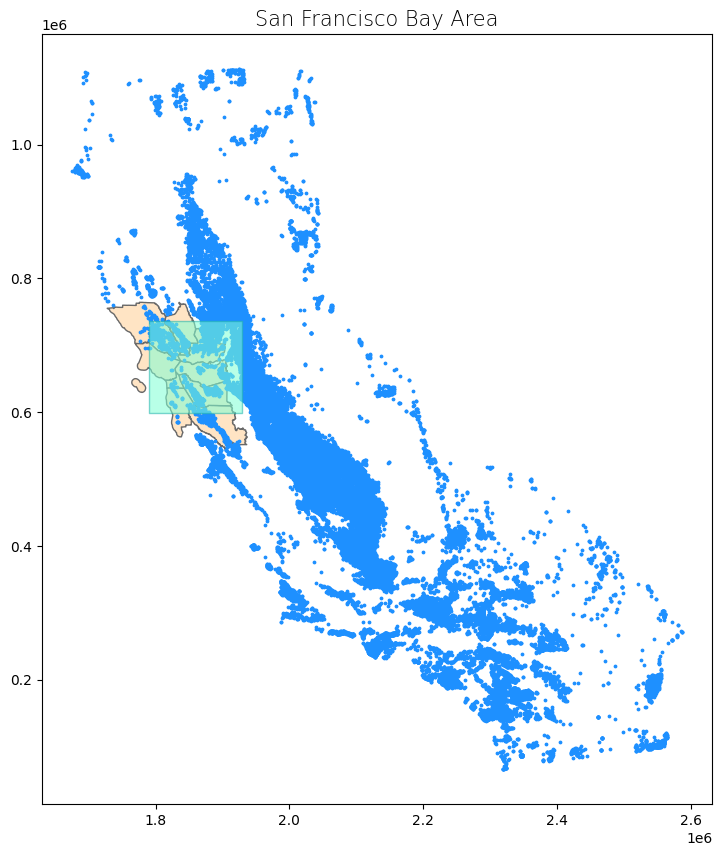

In [8]:
# Create subplots
fig, ax = plt.subplots(1, 1, figsize = (10, 10))

# Plot data
counties.plot(ax = ax, color = 'bisque', edgecolor = 'dimgray')
wells.plot(ax = ax, marker = 'o', color = 'dodgerblue', markersize = 3)
poly.plot(ax = ax, color = 'aquamarine', edgecolor = 'lightseagreen', alpha = 0.55)

# Stylize plots
plt.style.use('bmh')

# Set title
ax.set_title('San Francisco Bay Area', fontdict = {'fontsize': '15', 'fontweight' : '3'})

,fipst,fipco,coname,geometry
6,06,085,None,"POLYGON ((1849513.743 598437.644, 1849516.319 ..."
8,06,081,None,"POLYGON ((1824620.608 598957.373, 1824615.39 5..."
7,06,001,None,"POLYGON ((1842904.446 635585.861, 1842846.78 6..."
1,06,075,None,"POLYGON ((1828782.706 650763.837, 1829836.435 ..."
5,06,013,None,"POLYGON ((1844547.064 657302.253, 1844531.633 ..."
2,06,041,None,"POLYGON ((1791829.77 702650.089, 1791932.215 7..."
4,06,095,None,"POLYGON ((1863138.714 702814.904, 1862870.072 ..."
0,06,097,None,"POLYGON ((1813605.103 736060.767, 1813555.59 7..."
3,06,055,None,"POLYGON ((1856673.293 736098.588, 1856691.032 ..."


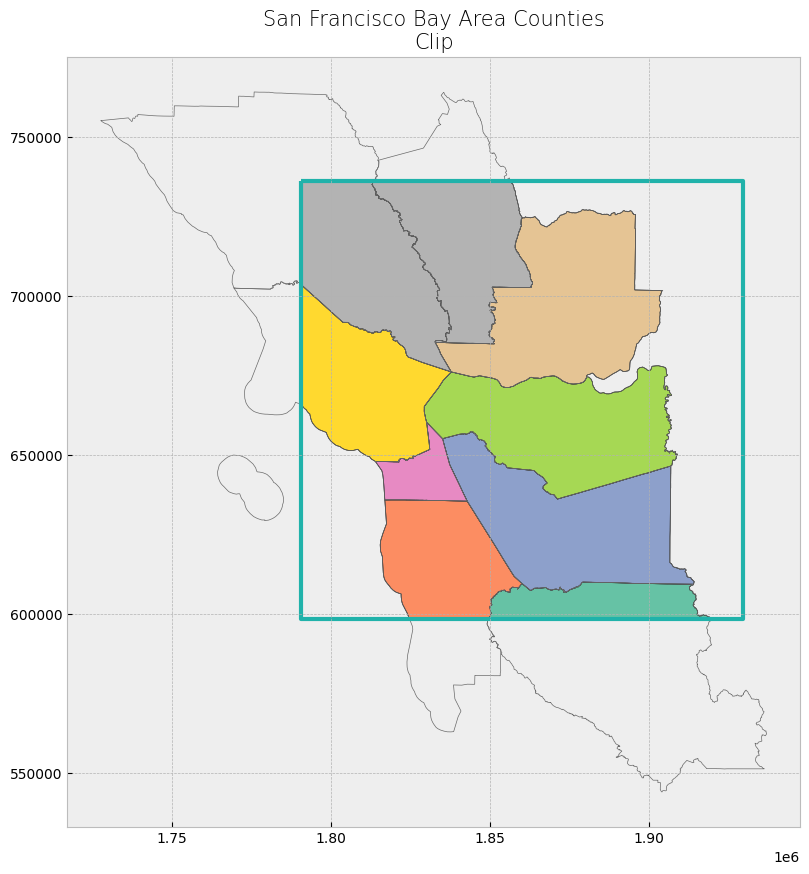

In [9]:
# Clip data
clip_counties = gpd.clip(counties, poly)

# Display attribute table
display(clip_counties)

# Plot clip
plot_df(result_name = "San Francisco Bay Area Counties\nClip", result_df = clip_counties, result_geom_type = "polygon", area = poly)

,OBJECTID,SITE_CODE,WELL_NAME,SWN,STN_ID,WCR_NO,LOC_DESC,WELL_USE,WELL_TYPE,WELL_DEPTH,...,MONITORING,LAST_MEAS_,LAST_MEA_1,STN_CMT,STN_MOD_DA,STN_MOD_BY,SOURCE,LAST_UPDAT,GlobalID,geometry
40579,40580,374517N1224295W001,05S05W32K001M,05S05W32K001M,7008,None,None,Unknown,Unknown,38.0,...,VOLUNTARY,Department of Water Resources,Department of Water Resources,None,2023-09-26,None,DWR EWM DB,2024-09-25,{E097559B-CF5D-48CF-B367-B95C98C695EE},POINT (1829296.287 607379.559)
21229,21230,374643N1224317W001,Pilarcitos Creek W1,05S05W29P001M,40046,20202,Kelly Street and Church Street Area,Irrigation,Single Well,84.0,...,CASGEM,Department of Water Resources,Department of Water Resources,Coastside County Water District received permi...,2024-07-16,None,DWR EWM DB,2024-09-25,{7B320EB7-4437-4AAC-8CBE-93A7F90C9FAE},POINT (1829130.54 608781.622)
23677,23678,374011N1221231W001,06S02W19B002,06S02W19B002M,56480,None,"End of Estrallita Take the bike path, the well...",Observation,Single Well,295.0,...,SGMA,Santa Clara Valley Water District - Santa Clara,Santa Clara Valley Water District,Coordinate method is combination of GPS and di...,2023-06-06,None,DWR EWM DB,2024-09-25,{B7242DD5-F3A7-49FD-8D63-6723D787E015},POINT (1856307.007 601251.365)
8077,8078,374069N1220886W001,06S02W16L021,06S02W16L021M,47609,0914620,7N SAN LUIS/130W FARLEY,Observation,Single Well,40.0,...,SGMA,Santa Clara Valley Water District - Santa Clara,Santa Clara Valley Water District,Coordinate method is combination of GPS and di...,2023-06-06,None,DWR EWM DB,2024-09-25,{FC0AD1AF-F079-401C-B130-6DA1ACC5781D},POINT (1859366.708 601842.634)
23863,23864,374090N1221168W001,06S02W18J001,06S02W18J001M,47610,184218,528N MILLER AVE/137E MONROE DR,Observation,Single Well,46.0,...,SGMA,Santa Clara Valley Water District - Santa Clara,Santa Clara Valley Water District,Coordinate method is combination of GPS and di...,2023-06-06,None,DWR EWM DB,2024-09-25,{C4A0BD27-F3C5-43E9-A1A7-5FE7D56BEAF1},POINT (1856912.911 602135.505)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3528,3529,386222N1214458W001,SAC-143,09N05E21E002M,52237,77994,None,Other,Single Well,330.0,...,VOLUNTARY,Sacramento Groundwater Authority,Sacramento Groundwater Authority,None,2021-12-15,None,DWR EWM DB,2024-09-25,{6987140F-7C5C-4A0F-8AC6-05ADF7E453AB},POINT (1917633.571 735950.159)
3521,3522,386220N1214766W001,SAC-093,09N05E19F001M,52221,21011,None,Other,Single Well,328.0,...,VOLUNTARY,Sacramento Groundwater Authority,Sacramento Groundwater Authority,None,2021-12-15,None,DWR EWM DB,2024-09-25,{9C449B28-434C-4C8A-823D-BE6724F11EFB},POINT (1914951.105 735960.836)
3481,3482,386229N1214138W001,SSWD 43,09N05E22A001M,52410,None,Edison/Truax,Other,Single Well,390.0,...,VOLUNTARY,Department of Water Resources,Sacramento Groundwater Authority,None,2021-12-15,None,DWR EWM DB,2024-09-25,{4C06134D-F4E2-4400-B9B0-061D2AE86173},POINT (1920423.042 735999.713)
7720,7721,386238N1213744W001,24,None,51634,None,None,Unknown,Single Well,360.0,...,VOLUNTARY,Department of Water Resources,Department of Water Resources,None,2021-12-15,None,DWR EWM DB,2024-09-25,{2118EE76-505C-4361-B6B1-29366B07D213},POINT (1923853.948 736074.4)


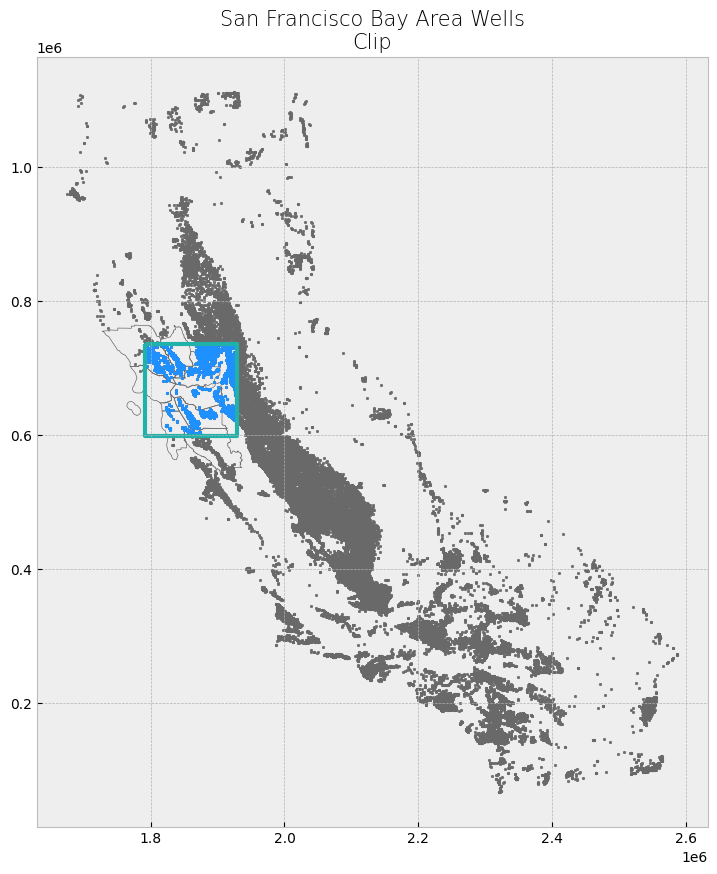

In [10]:
# Clip data
clip_wells = gpd.clip(wells, poly)

# Display attribute table
display(clip_wells)

# Plot clip
plot_df(result_name = "San Francisco Bay Area Wells\nClip", result_df = clip_wells, result_geom_type = "point", area = poly)

In [11]:
# Display attribute table
display(wells.head(2))

,OBJECTID,SITE_CODE,WELL_NAME,SWN,STN_ID,WCR_NO,LOC_DESC,WELL_USE,WELL_TYPE,WELL_DEPTH,...,MONITORING,LAST_MEAS_,LAST_MEA_1,STN_CMT,STN_MOD_DA,STN_MOD_BY,SOURCE,LAST_UPDAT,GlobalID,geometry
0,1,344238N1196128W001,3-23,None,61095,None,next to house in walled region by trash,Residential,Single Well,435.0,...,SGMA,None,None,None,2024-09-20,None,DWR EWM DB,2024-09-25,{DB05DE98-CBFF-4537-A2C4-3420D4E29784},POINT (2081683.705 269860.261)
1,2,344218N1196224W001,3-24,None,61096,None,near large avo tree and road,Residential,Single Well,325.0,...,SGMA,None,None,None,2024-09-20,None,DWR EWM DB,2024-09-25,{51656FF0-0034-4E7E-B8F0-4DB552122841},POINT (2080799.161 269634.143)


In [12]:
# Select wells that are public supply
wells_public = wells[(wells["WELL_USE"] == "Public Supply")]

# Display first two and last two rows of attribute table
display_table(table_name = "San Francisco Bay Area Wells - Public Supply", attribute_table = wells_public)

Attribute Table: San Francisco Bay Area Wells - Public Supply

Table shape (rows, columns): (827, 28)

First two rows:


,OBJECTID,SITE_CODE,WELL_NAME,SWN,STN_ID,WCR_NO,LOC_DESC,WELL_USE,WELL_TYPE,WELL_DEPTH,...,MONITORING,LAST_MEAS_,LAST_MEA_1,STN_CMT,STN_MOD_DA,STN_MOD_BY,SOURCE,LAST_UPDAT,GlobalID,geometry
13,14,344050N1195284W001,29D8,04N25W29D008S,60454,None,Unknown,Public Supply,Single Well,958.0,...,SGMA,None,None,None,2024-03-06,None,DWR EWM DB,2024-09-25,{F0E0A245-78D2-46F3-B3A7-8AD4E89ADBA6},POINT (2089472.969 267849.375)
15,16,342331N1171801W001,ROCKY POINT WELL,None,60973,None,None,Public Supply,Single Well,NaN,...,VOLUNTARY,None,None,CA3600258_001_001,2024-08-26,None,DWR EWM DB,2024-09-25,{1DCED7E6-FD18-4AD3-9D5F-F3E58A17DD0F},POINT (2306347.974 253716.921)



Last two rows:


,OBJECTID,SITE_CODE,WELL_NAME,SWN,STN_ID,WCR_NO,LOC_DESC,WELL_USE,WELL_TYPE,WELL_DEPTH,...,MONITORING,LAST_MEAS_,LAST_MEA_1,STN_CMT,STN_MOD_DA,STN_MOD_BY,SOURCE,LAST_UPDAT,GlobalID,geometry
46206,46207,338732N1175868W001,Corona 14,03S07W35C001S,57106,None,None,Public Supply,Single Well,515.0,...,SGMA,Temescal Subbasin GSA,Temescal Subbasin GSA,None,2024-09-10,None,DWR EWM DB,2024-09-25,{215FAB95-B34C-4FC9-9C9D-9C37B1EB7B11},POINT (2270077.341 212486.161)
46321,46322,340618N1170368W001,YVWD-37,None,57257,None,700 ft W and 440 ft S of Carter St and Bryant ...,Public Supply,Single Well,700.0,...,SGMA,Yucaipa Basin GSA,Yucaipa Basin GSA,None,2024-06-10,None,DWR EWM DB,2024-09-25,{9CBC6563-F61C-420A-94AB-F1E20D824B9F},POINT (2320265.14 235171.77)


In [13]:
# Select wells that are public supply and have a depth greater than 50 ft
wells_public_deep = wells[(wells["WELL_USE"] == "Public Supply") & (wells["WELL_DEPTH"] > 50)]

# Display first two and last two rows of attribute table
display_table(table_name = "San Francisco Bay Area Wells - Public Supply with Depth Greater than 50 ft", attribute_table = wells_public_deep)

Attribute Table: San Francisco Bay Area Wells - Public Supply with Depth Greater than 50 ft

Table shape (rows, columns): (483, 28)

First two rows:


,OBJECTID,SITE_CODE,WELL_NAME,SWN,STN_ID,WCR_NO,LOC_DESC,WELL_USE,WELL_TYPE,WELL_DEPTH,...,MONITORING,LAST_MEAS_,LAST_MEA_1,STN_CMT,STN_MOD_DA,STN_MOD_BY,SOURCE,LAST_UPDAT,GlobalID,geometry
13,14,344050N1195284W001,29D8,04N25W29D008S,60454,None,Unknown,Public Supply,Single Well,958.0,...,SGMA,None,None,None,2024-03-06,None,DWR EWM DB,2024-09-25,{F0E0A245-78D2-46F3-B3A7-8AD4E89ADBA6},POINT (2089472.969 267849.375)
17,18,380380N1202312W001,WELL NO. 1,None,60975,0994083,None,Public Supply,Single Well,900.0,...,VOLUNTARY,None,None,CA5510005-004,2024-08-27,None,DWR EWM DB,2024-09-25,{259E578A-236C-47B4-A817-04862C5CABBA},POINT (2023591.347 670731.016)



Last two rows:


,OBJECTID,SITE_CODE,WELL_NAME,SWN,STN_ID,WCR_NO,LOC_DESC,WELL_USE,WELL_TYPE,WELL_DEPTH,...,MONITORING,LAST_MEAS_,LAST_MEA_1,STN_CMT,STN_MOD_DA,STN_MOD_BY,SOURCE,LAST_UPDAT,GlobalID,geometry
46206,46207,338732N1175868W001,Corona 14,03S07W35C001S,57106,None,None,Public Supply,Single Well,515.0,...,SGMA,Temescal Subbasin GSA,Temescal Subbasin GSA,None,2024-09-10,None,DWR EWM DB,2024-09-25,{215FAB95-B34C-4FC9-9C9D-9C37B1EB7B11},POINT (2270077.341 212486.161)
46321,46322,340618N1170368W001,YVWD-37,None,57257,None,700 ft W and 440 ft S of Carter St and Bryant ...,Public Supply,Single Well,700.0,...,SGMA,Yucaipa Basin GSA,Yucaipa Basin GSA,None,2024-06-10,None,DWR EWM DB,2024-09-25,{9CBC6563-F61C-420A-94AB-F1E20D824B9F},POINT (2320265.14 235171.77)


In [14]:
# Select wells that are public supply and have a depth greater than 50 ft OR are residential
wells_public_deep_residential = wells[((wells["WELL_USE"] == "Public Supply") & (wells["WELL_DEPTH"] > 50)) | (wells["WELL_USE"] == "Residential")]

# Display first two and last two rows of attribute table
display_table(table_name = "San Francisco Bay Area Wells - Public Supply with Depth Greater than 50 ft or Residential", attribute_table = wells_public_deep_residential)

Attribute Table: San Francisco Bay Area Wells - Public Supply with Depth Greater than 50 ft or Residential

Table shape (rows, columns): (2764, 28)

First two rows:


,OBJECTID,SITE_CODE,WELL_NAME,SWN,STN_ID,WCR_NO,LOC_DESC,WELL_USE,WELL_TYPE,WELL_DEPTH,...,MONITORING,LAST_MEAS_,LAST_MEA_1,STN_CMT,STN_MOD_DA,STN_MOD_BY,SOURCE,LAST_UPDAT,GlobalID,geometry
0,1,344238N1196128W001,3-23,None,61095,None,next to house in walled region by trash,Residential,Single Well,435.0,...,SGMA,None,None,None,2024-09-20,None,DWR EWM DB,2024-09-25,{DB05DE98-CBFF-4537-A2C4-3420D4E29784},POINT (2081683.705 269860.261)
1,2,344218N1196224W001,3-24,None,61096,None,near large avo tree and road,Residential,Single Well,325.0,...,SGMA,None,None,None,2024-09-20,None,DWR EWM DB,2024-09-25,{51656FF0-0034-4E7E-B8F0-4DB552122841},POINT (2080799.161 269634.143)



Last two rows:


,OBJECTID,SITE_CODE,WELL_NAME,SWN,STN_ID,WCR_NO,LOC_DESC,WELL_USE,WELL_TYPE,WELL_DEPTH,...,MONITORING,LAST_MEAS_,LAST_MEA_1,STN_CMT,STN_MOD_DA,STN_MOD_BY,SOURCE,LAST_UPDAT,GlobalID,geometry
46610,46611,344622N1171548W001,04N03W01M01,04N03W01M001S,4350,None,None,Residential,Single Well,730.0,...,VOLUNTARY,Mojave Water Agency,US Geological Survey,None,2021-12-15,None,DWR EWM DB,2024-09-25,{6BDE5258-5DC8-4CDC-88EC-E0EB4A99C2C0},POINT (2307852.78 279242.476)
46782,46783,357704N1177250W001,Charely Tower,25S39E12R001M,55378,None,NAWS China Lake,Residential,Single Well,150.0,...,SGMA,Indian Wells Valley Groundwater Authority GSA,U S DEPARTMENT OF NAVY,None,2023-05-30,None,DWR EWM DB,2024-09-25,{278A12A2-0CCE-4D3F-BE82-E3A38E265777},POINT (2251025.725 422736.238)


# Select by Location
## Shapely Vector

Attribute Table: San Francisco Bay Area Wells within a User-Defined Rectangle

Table shape (rows, columns): (2641, 28)

First two rows:


,OBJECTID,SITE_CODE,WELL_NAME,SWN,STN_ID,WCR_NO,LOC_DESC,WELL_USE,WELL_TYPE,WELL_DEPTH,...,MONITORING,LAST_MEAS_,LAST_MEA_1,STN_CMT,STN_MOD_DA,STN_MOD_BY,SOURCE,LAST_UPDAT,GlobalID,geometry
59,60,379880N1216381W001,SOUTH PARK WELL - STANDBY,None,60987,None,None,Public Supply,Single Well,NaN,...,VOLUNTARY,None,None,CA0710007_005_005,2024-08-27,None,DWR EWM DB,2024-09-25,{31AED324-D99D-42D8-8683-DBE6DEEB145D},POINT (1900028.06 665753.34)
80,81,379739N1216848W001,GLEN PARK WELL,None,60986,None,None,Public Supply,Single Well,NaN,...,VOLUNTARY,None,None,CA0710007_005_005,2024-08-27,None,DWR EWM DB,2024-09-25,{B18B1FCC-A232-4607-BB47-748D91ACC815},POINT (1895901.897 664239.487)



Last two rows:


,OBJECTID,SITE_CODE,WELL_NAME,SWN,STN_ID,WCR_NO,LOC_DESC,WELL_USE,WELL_TYPE,WELL_DEPTH,...,MONITORING,LAST_MEAS_,LAST_MEA_1,STN_CMT,STN_MOD_DA,STN_MOD_BY,SOURCE,LAST_UPDAT,GlobalID,geometry
46473,46474,382526N1221665W001,05N03W26F002M,05N03W26F002M,9244,None,None,Irrigation,Unknown,282.0,...,VOLUNTARY,Department of Water Resources,Solano Irrigation District,None,2023-09-26,None,DWR EWM DB,2024-09-25,{D1CDC43F-3A30-41E4-8259-3A35A645DF4C},POINT (1854144.308 695807.828)
46474,46475,383598N1223107W001,06N04W16P001M,06N04W16P001M,37367,None,None,Residential,Unknown,76.0,...,VOLUNTARY,Department of Water Resources,Napa County,None,2023-09-26,None,DWR EWM DB,2024-09-25,{05286D01-1EBB-47C5-BF74-7AE500B5B1A1},POINT (1841755.238 707939.225)


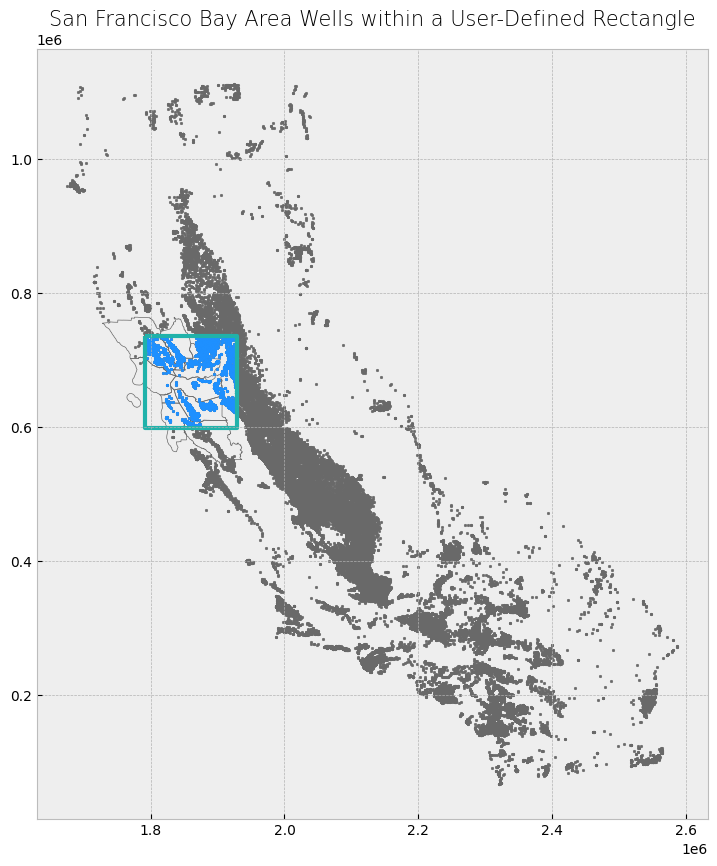

In [15]:
# Select wells that fall within Shapely rectangle
wells_within_rect_shapely = wells[wells.within(poly_shapely)]

# Display first two and last two rows of attribute table
display_table(table_name = "San Francisco Bay Area Wells within a User-Defined Rectangle", attribute_table = wells_within_rect_shapely)

# Plot selection
plot_df(result_name = "San Francisco Bay Area Wells within a User-Defined Rectangle", result_df = wells_within_rect_shapely, result_geom_type = "point", area = poly)

In [16]:
# Select the Santa Clara County boundary
sc_county = counties[counties["coname"] == "Santa Clara County"]

# Subset the GeoDataFrame by checking which wells are within Santa Clara County's Shapely object
wells_within_sc_shapely = wells[wells.within(sc_county.geometry.values[0])]

# Display first two and last two rows of attribute table
display_table(table_name = "San Francisco Bay Area Wells within Santa Clara County", attribute_table = wells_within_sc_shapely)

# Plot selection
plot_df(result_name = "San Francisco Bay Area Wells within Santa Clara County", result_df = wells_within_sc_shapely, result_geom_type = "point", area = sc_county)

IndexError: index 0 is out of bounds for axis 0 with size 0